## Load

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")
dataset_path = "/".join((path, "mushrooms.csv"))

print("Path to dataset files:", path)

100%|██████████| 34.2k/34.2k [00:00<00:00, 13.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1


In [ ]:
df = pd.read_csv(dataset_path)
pd.set_option('display.max_columns', None)
df.head()
# print(df)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


## Data Exploration

### describe

In [ ]:
import numpy as np
print(df.info())
# display(df.select_dtypes(exclude=[np.number]).describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### isna

In [ ]:
print("Nan values:")
display(df.isna().sum().sort_values(ascending=False))


Nan values:


,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


### Categorical features distribution

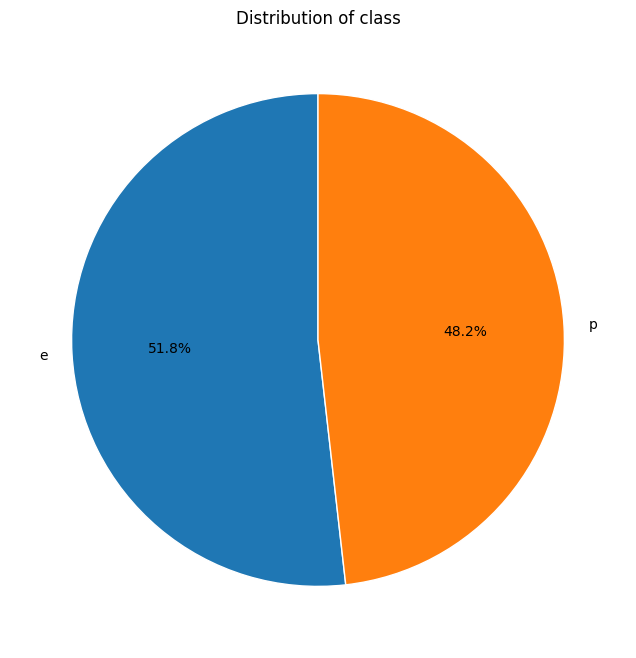

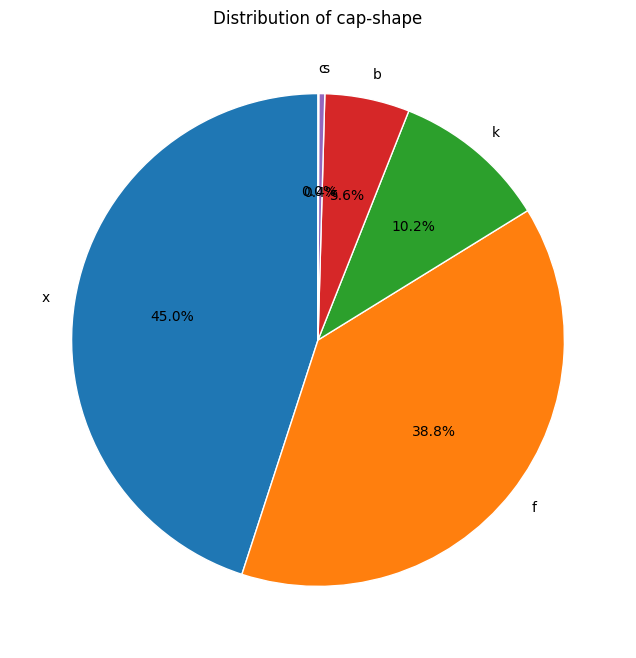

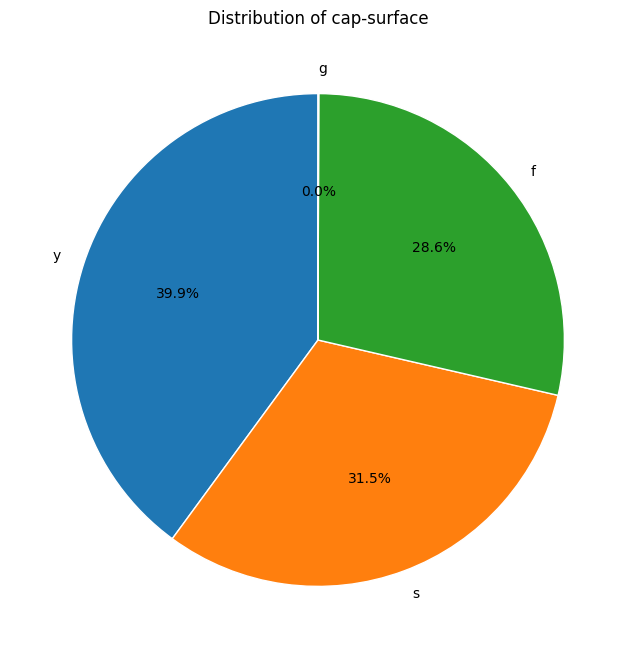

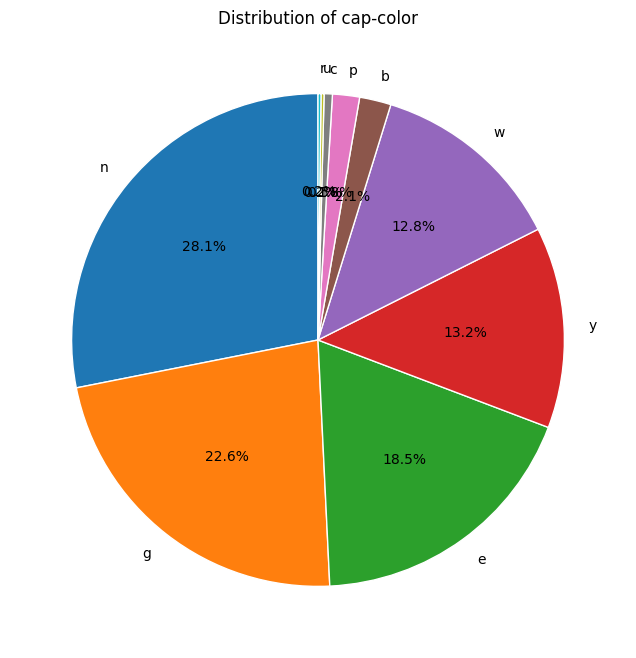

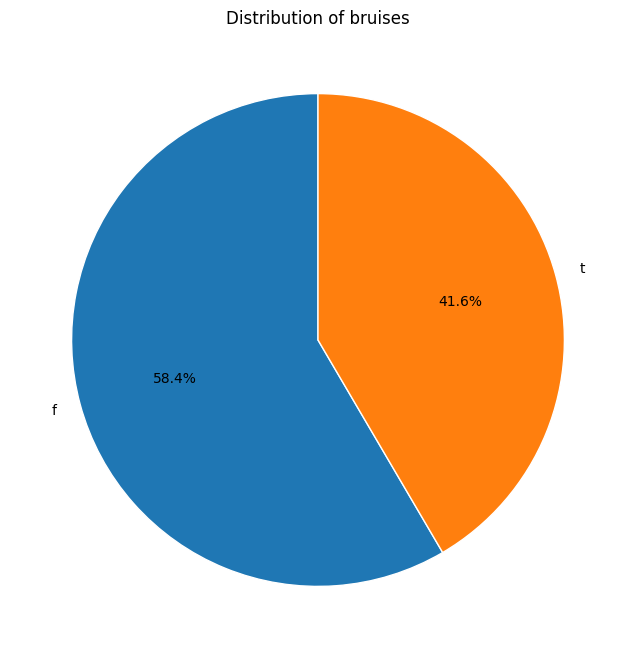

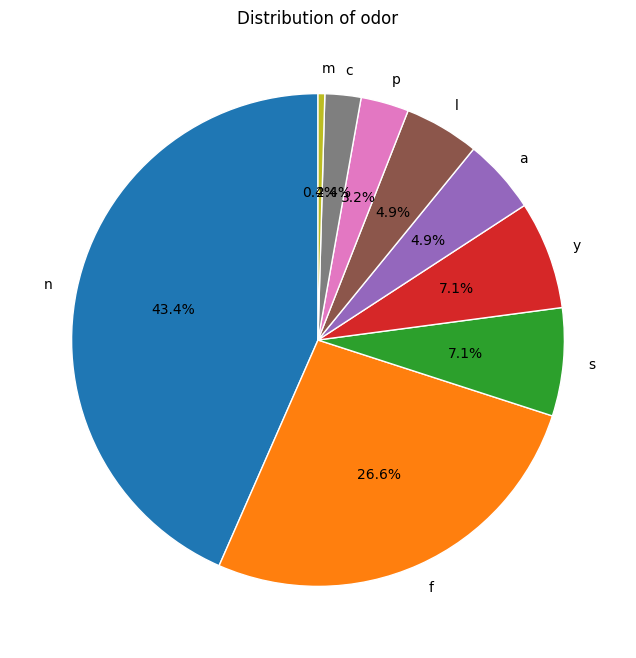

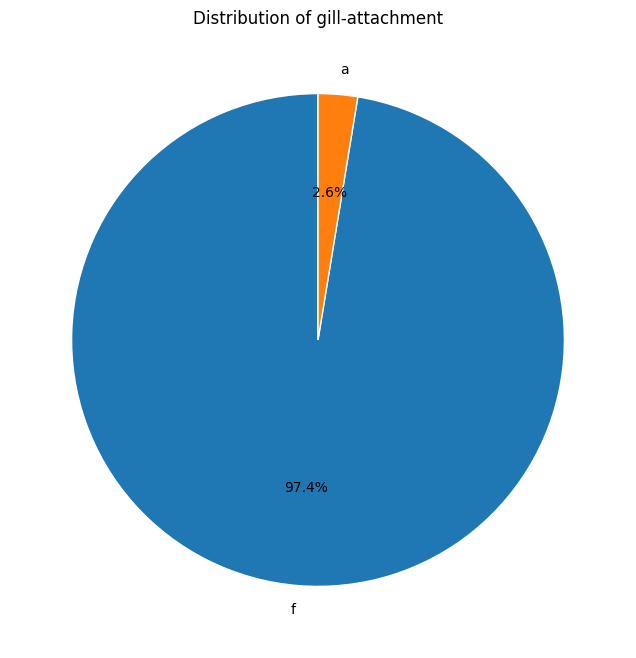

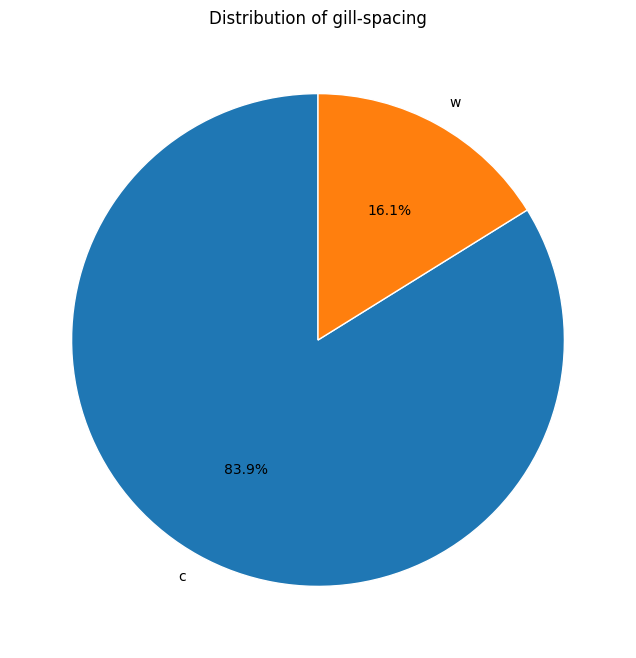

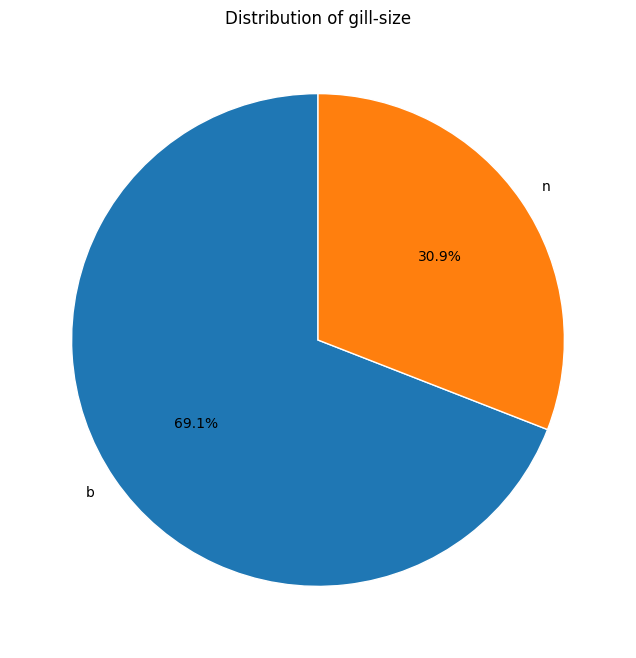

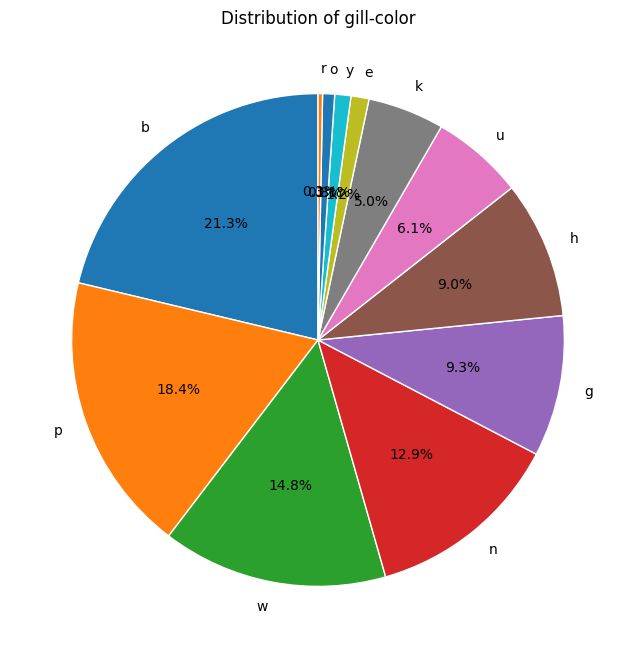

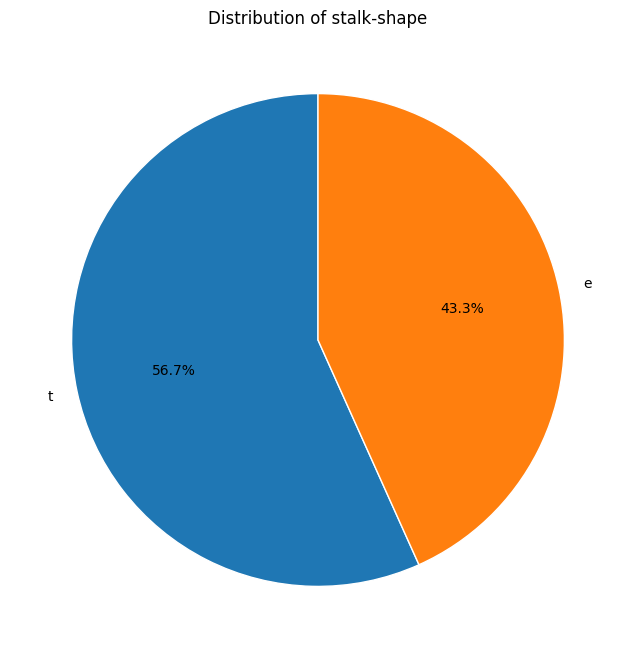

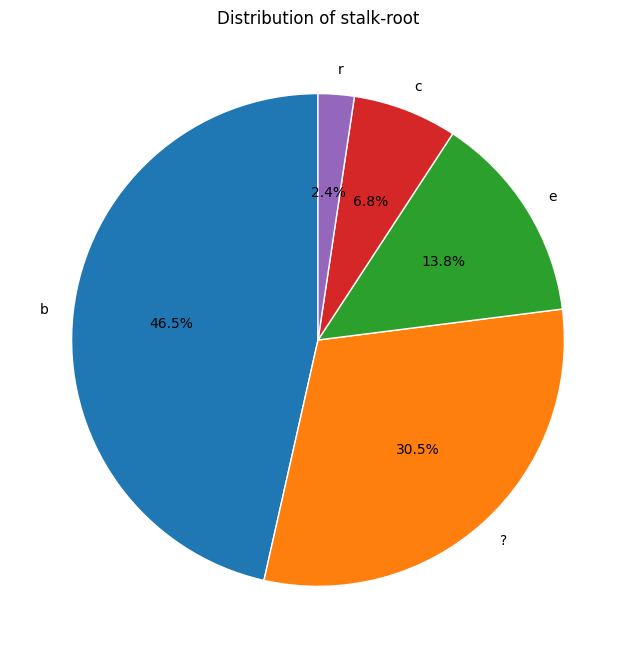

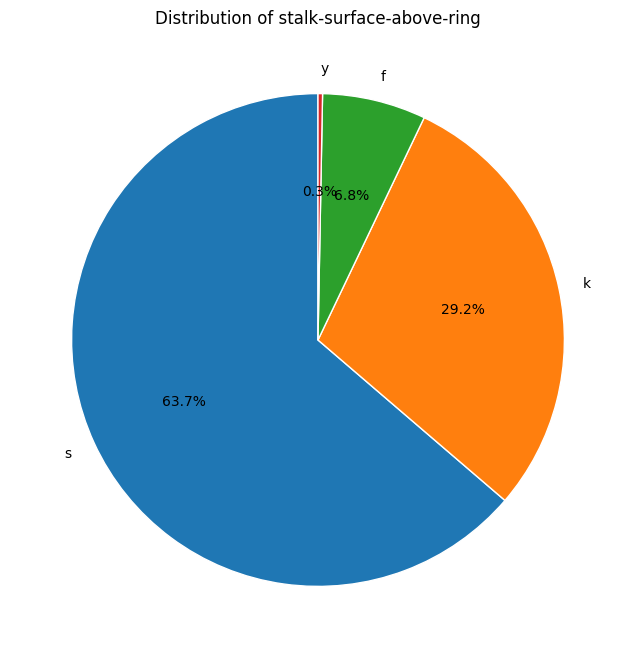

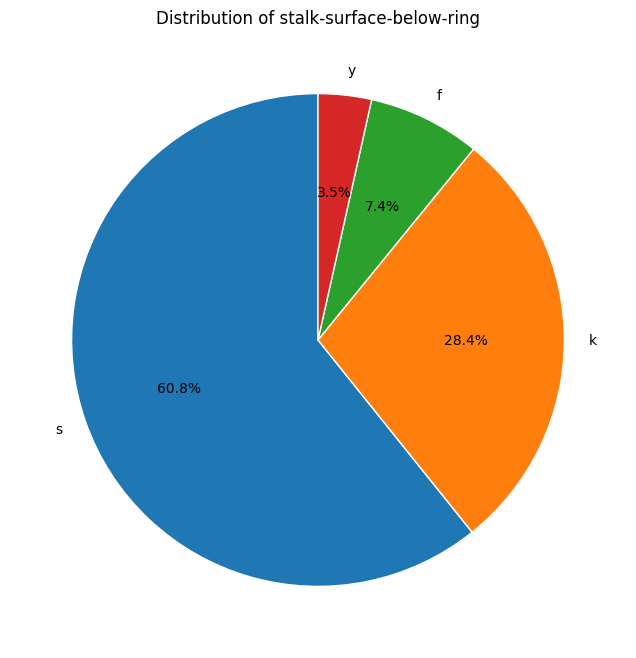

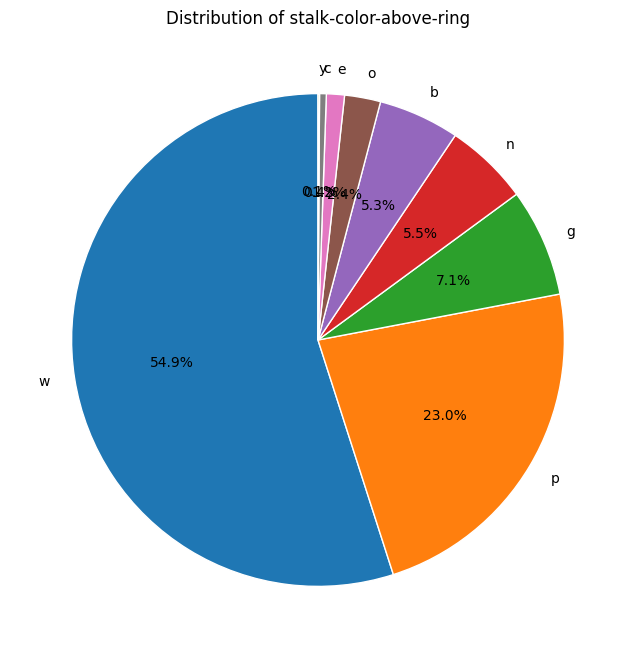

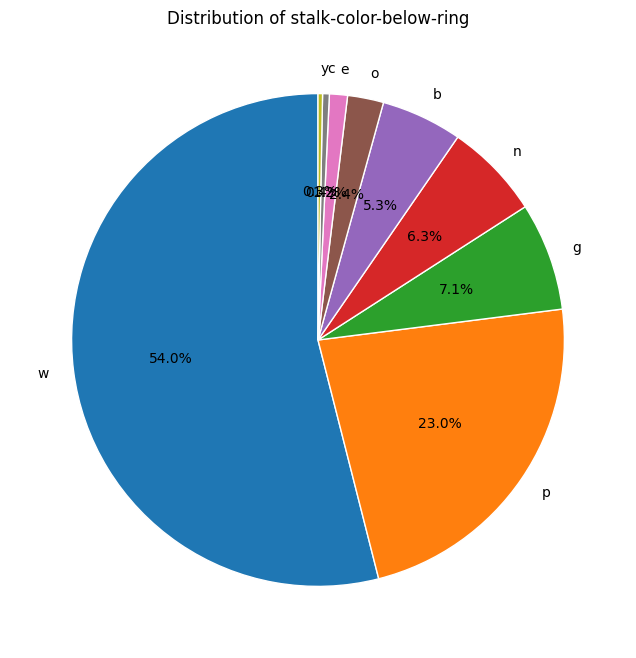

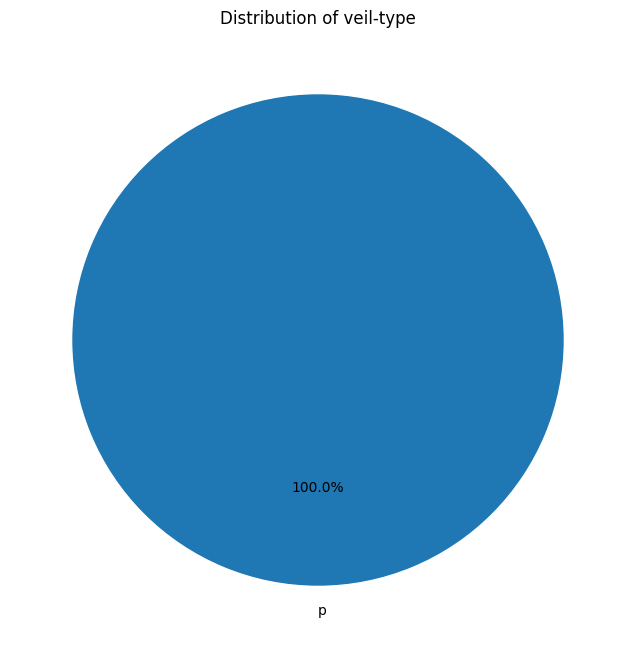

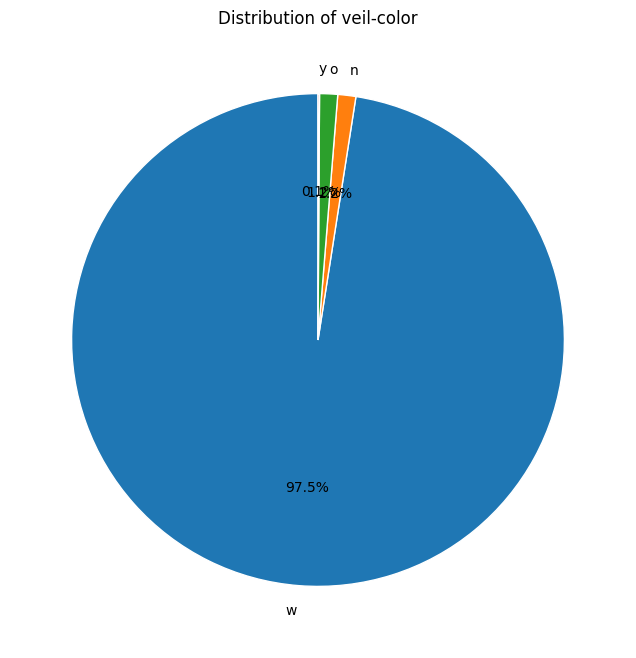

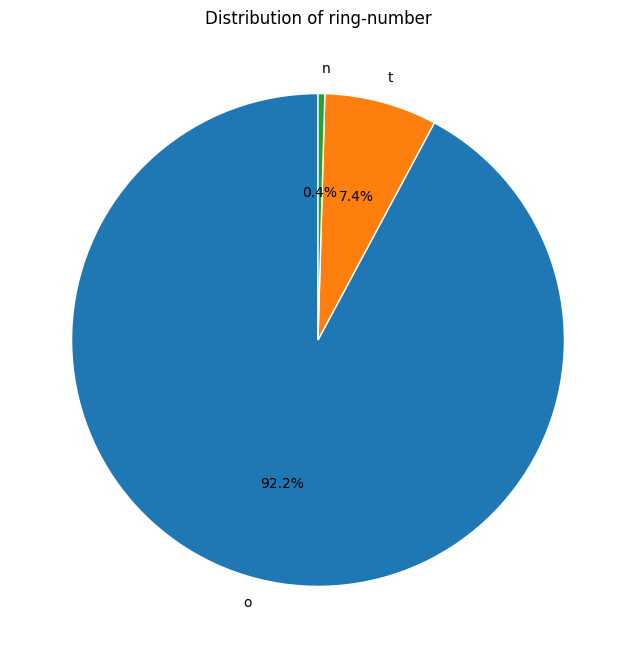

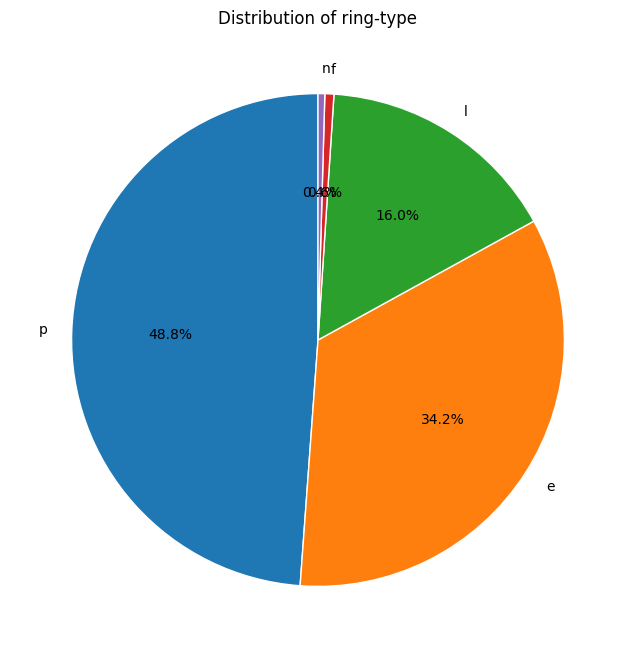

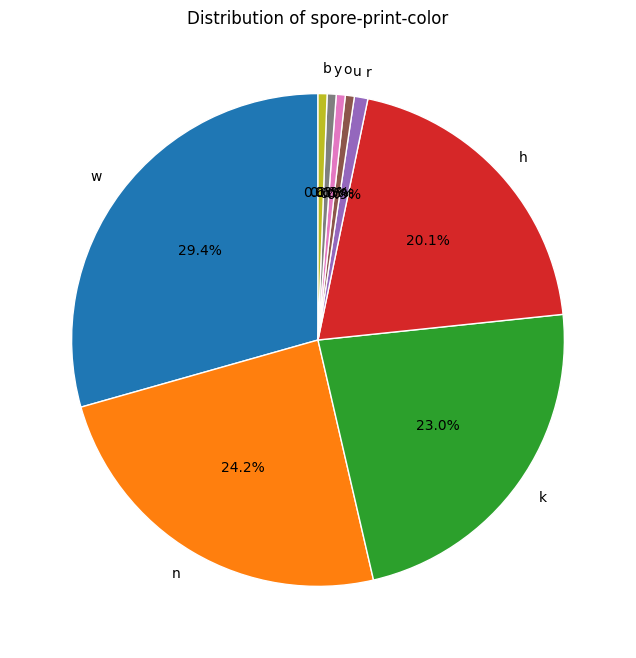

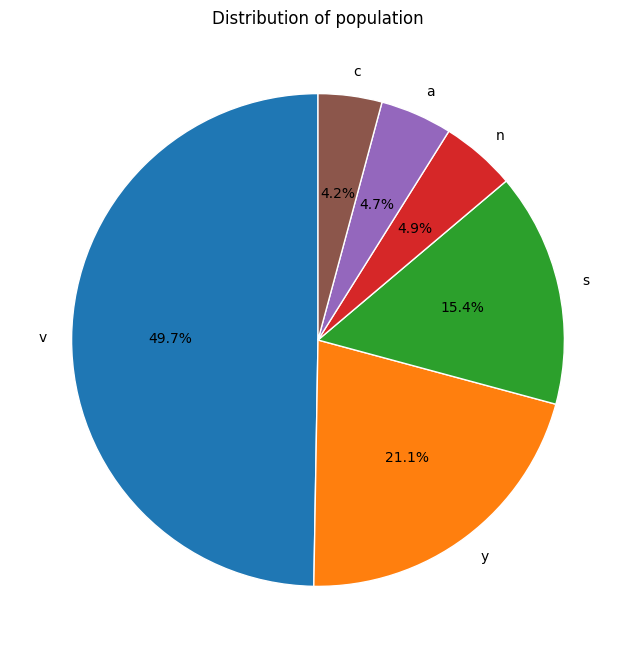

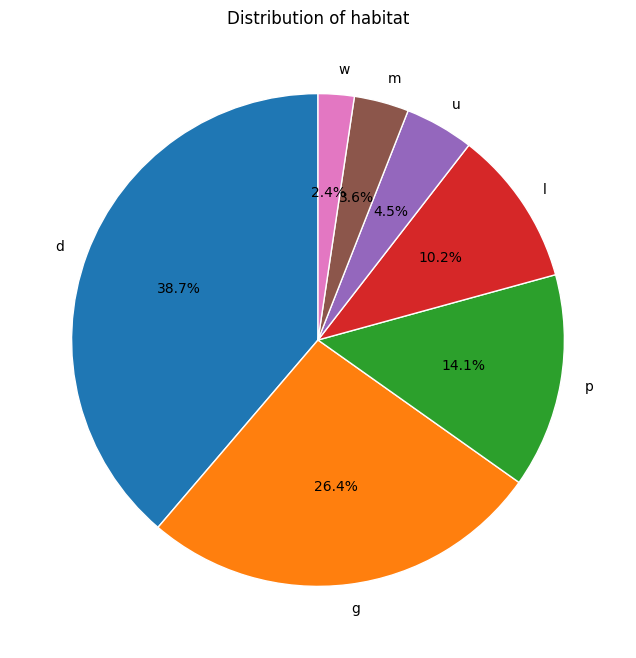

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8, 8))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
    plt.title(f'Distribution of {col}')
    plt.ylabel('') # Remove default y-label
    plt.show()

## Missing Values

In [ ]:
import numpy as np

df['stalk-root'] = df['stalk-root'].replace('?', np.nan)
display(df['stalk-root'].value_counts(dropna=False))

,count
stalk-root,
b,3776
NaN,2480
e,1120
c,556
r,192


In [ ]:
miss_df = df.dropna(subset=['stalk-root']).copy()
display(miss_df.head())

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# Prepare data - predict 'stalk-root' using other features
X = miss_df.drop('stalk-root', axis=1)
y = miss_df['stalk-root']

# Identify categorical features (all features except the target)
categorical_features = X.columns.tolist()

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='passthrough'
)

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define parameter grid for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [None, 5, 10]
}

# Instantiate and fit GridSearchCV with 5-fold cross-validation
grid_search_rf_stalk_root = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search_rf_stalk_root.fit(X, y)

# Print best parameters and best cross-validation score
print(f"\nBest Random Forest Model Parameters for Stalk-Root Prediction: {grid_search_rf_stalk_root.best_params_}")
print(f"Best Cross-validation Accuracy for Stalk-Root Prediction: {grid_search_rf_stalk_root.best_score_:.4f}")

# Evaluate on the entire miss_df dataset for a full report
y_pred_stalk_root = grid_search_rf_stalk_root.predict(X)
accuracy_stalk_root = accuracy_score(y, y_pred_stalk_root)
cm_stalk_root = confusion_matrix(y, y_pred_stalk_root)
report_stalk_root = classification_report(y, y_pred_stalk_root)

print(f"\nAccuracy on miss_df (Stalk-Root Prediction): {accuracy_stalk_root}")
print("Confusion Matrix on miss_df (Stalk-Root Prediction):")
print(cm_stalk_root)
print("Classification Report on miss_df (Stalk-Root Prediction):")
print(report_stalk_root)


Best Random Forest Model Parameters for Stalk-Root Prediction: {'classifier__max_depth': None, 'classifier__n_estimators': 50}
Best Cross-validation Accuracy for Stalk-Root Prediction: 0.9922

Accuracy on miss_df (Stalk-Root Prediction): 1.0
Confusion Matrix on miss_df (Stalk-Root Prediction):
[[3776    0    0    0]
 [   0  556    0    0]
 [   0    0 1120    0]
 [   0    0    0  192]]
Classification Report on miss_df (Stalk-Root Prediction):
              precision    recall  f1-score   support

           b       1.00      1.00      1.00      3776
           c       1.00      1.00      1.00       556
           e       1.00      1.00      1.00      1120
           r       1.00      1.00      1.00       192

    accuracy                           1.00      5644
   macro avg       1.00      1.00      1.00      5644
weighted avg       1.00      1.00      1.00      5644



In [ ]:
missing_stalk_root_rows = df[df['stalk-root'].isna()].copy()
X_missing = missing_stalk_root_rows.drop('stalk-root', axis=1)
predicted_stalk_root = grid_search_rf_stalk_root.predict(X_missing)
df.loc[missing_stalk_root_rows.index, 'stalk-root'] = predicted_stalk_root

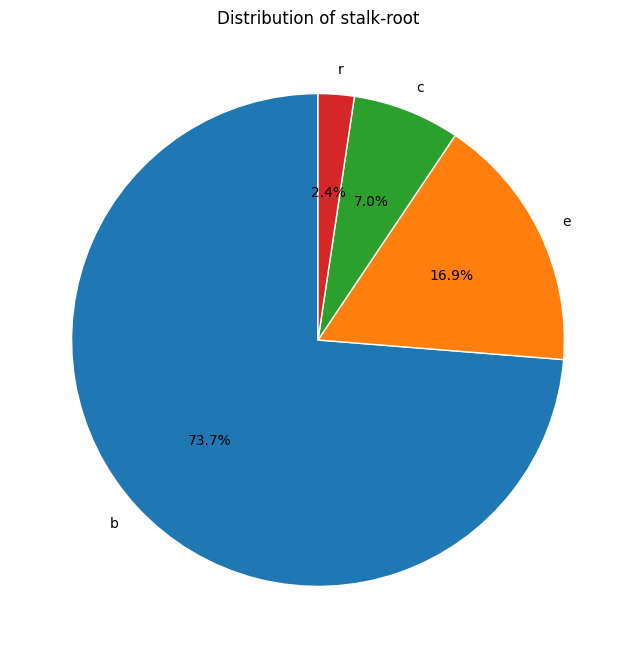

In [ ]:
plt.figure(figsize=(8, 8))
df['stalk-root'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title(f'Distribution of stalk-root')
plt.ylabel('') # Remove default y-label
plt.show()

## Feature selection

In [ ]:
df = df.drop(columns=['veil-type'])

## Define feature_sets


In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: []
Categorical features: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [ ]:
all_features = ['cap-shape', 'cap-surface', 'cap-color', 'bruises',
                'odor', 'gill-attachment', 'gill-spacing', 'gill-size',
                'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
                'stalk-surface-below-ring', 'stalk-color-above-ring',
                'stalk-color-below-ring', 'veil-color',
                'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
all_features.remove('stalk-root')
feature_sets = [all_features,
                ['cap-shape', 'cap-surface', 'cap-color'],
                ['gill-attachment', 'gill-spacing', 'gill-size','gill-color'],
                ['stalk-root', 'stalk-surface-above-ring',
                'stalk-surface-below-ring', 'stalk-color-above-ring',
                'stalk-color-below-ring']]

## Compare models


### logistic regression



Training Logistic Regression model with features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Mean Cross-validation score: 0.9995
Standard Deviation of Cross-validation score: 0.0007
Accuracy: 0.9987694831829368
Confusion Matrix:
[[1263    0]
 [   3 1172]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1263
           1       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

AUC: 0.9987234042553191


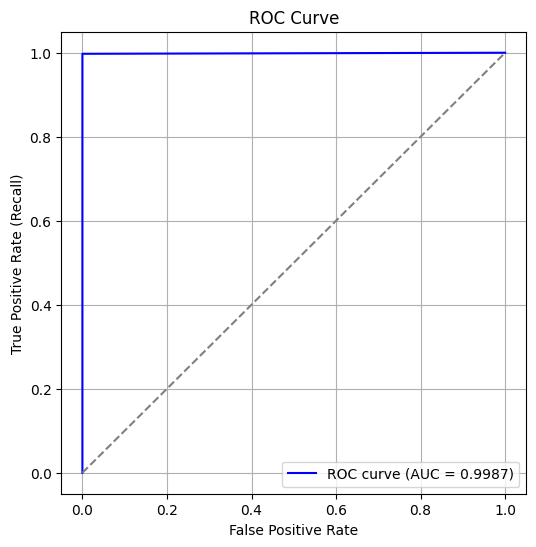


Training Logistic Regression model with features: ['cap-shape', 'cap-surface', 'cap-color']
Mean Cross-validation score: 0.6588
Standard Deviation of Cross-validation score: 0.0234
Accuracy: 0.6730926989335521
Confusion Matrix:
[[847 416]
 [381 794]]
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68      1263
           1       0.66      0.68      0.67      1175

    accuracy                           0.67      2438
   macro avg       0.67      0.67      0.67      2438
weighted avg       0.67      0.67      0.67      2438

AUC: 0.6731850878522936


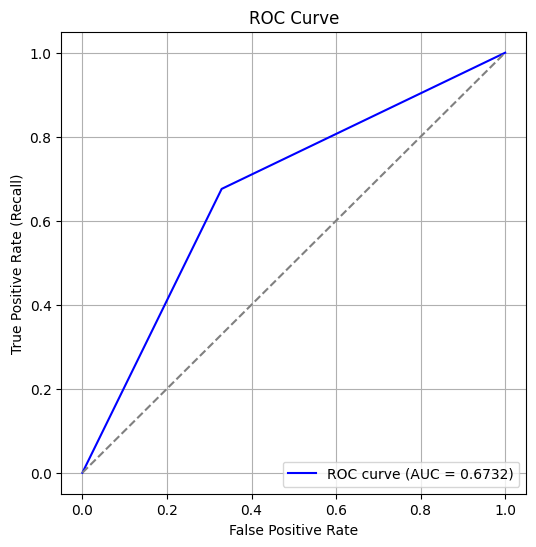


Training Logistic Regression model with features: ['gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']
Mean Cross-validation score: 0.8690
Standard Deviation of Cross-validation score: 0.0074
Accuracy: 0.8773584905660378
Confusion Matrix:
[[1189   74]
 [ 225  950]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1263
           1       0.93      0.81      0.86      1175

    accuracy                           0.88      2438
   macro avg       0.88      0.87      0.88      2438
weighted avg       0.88      0.88      0.88      2438

AUC: 0.8749599905661967


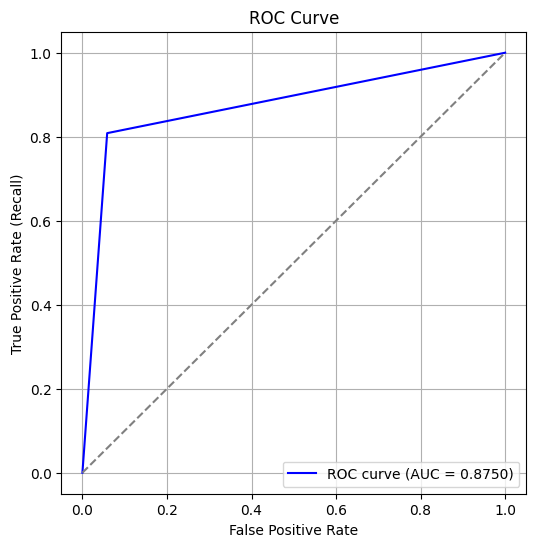


Training Logistic Regression model with features: ['stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring']
Mean Cross-validation score: 0.8461
Standard Deviation of Cross-validation score: 0.0119
Accuracy: 0.8367514356029533
Confusion Matrix:
[[ 993  270]
 [ 128 1047]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1263
           1       0.79      0.89      0.84      1175

    accuracy                           0.84      2438
   macro avg       0.84      0.84      0.84      2438
weighted avg       0.84      0.84      0.84      2438

AUC: 0.8386435538484863


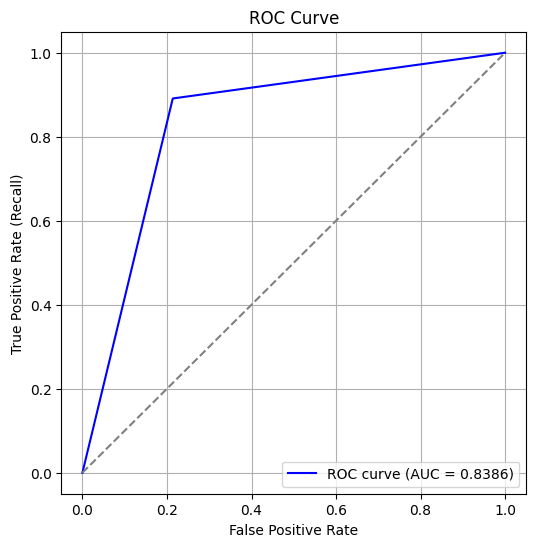

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score

import numpy as np

evaluation_results = []

for features in feature_sets:
    print(f"\nTraining Logistic Regression model with features: {features}")

    # Split data
    X = df[features]
    y = df['class']

    # Manual encoding of target variable
    y_encoded = y.map({'e': 0, 'p': 1})


    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

    # Identify numerical features
    cat_features = X_train.columns.tolist()

    # Create preprocessor
    # numeric_transformer = StandardScaler()


    preprocessor = ColumnTransformer(
        transformers=[
            ('class', OneHotEncoder(), cat_features),
        ],
        remainder='passthrough'
    )

    # Create and train pipeline for cross-validation
    cv_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ])

    cv_scores = cross_val_score(cv_pipeline, X_train, y_train, cv=5, scoring='accuracy')

    # Calculate the mean and standard deviation of the cross-validation scores
    mean_cv_score = np.mean(cv_scores)
    std_cv_score = np.std(cv_scores)

    # Print the mean and standard deviation
    print(f"Mean Cross-validation score: {mean_cv_score:.4f}")
    print(f"Standard Deviation of Cross-validation score: {std_cv_score:.4f}")


    # Create and train pipeline for test set evaluation
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ])
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    # report = classification_report(y_test, y_pred, target_names=['e', 'p']) # Add target_names
    report = classification_report(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    # Store results
    evaluation_results.append({
        'Model': 'Logistic Regression',
        'Features': features,
        'Accuracy': accuracy,
        'Confusion Matrix': cm,
        'Classification Report': report
    })

    print(f"Accuracy: {accuracy}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(report)
    print(f"AUC: {auc}")

    # Plot ROC curve
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

### decision tree


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

for features in feature_sets:
    print(f"\nTraining Decision Tree model with features: {features}")
    # Split data
    X = df[features]
    y = df['class']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Identify numerical features
    # numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_train.columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ],
        remainder='passthrough'
    )

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])

    # Define parameter grid for GridSearchCV
    param_grid = {
        'classifier__max_depth': [3, 5, 7, 10, None],
        'classifier__min_samples_split': [2, 5, 10]
    }

    # Instantiate and fit GridSearchCV
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Get the best estimator
    best_dt_model = grid_search.best_estimator_

    # Predict on the test set
    y_pred_dt = best_dt_model.predict(X_test)

    # Evaluate
    accuracy_dt = accuracy_score(y_test, y_pred_dt)
    cm_dt = confusion_matrix(y_test, y_pred_dt)
    report_dt = classification_report(y_test, y_pred_dt)

    # Store results
    evaluation_results.append({
        'Model': 'Decision Tree (Tuned)',
        'Features': features,
        'Accuracy': accuracy_dt,
        'Confusion Matrix': cm_dt,
        'Classification Report': report_dt
    })

    print(f"\nBest Decision Tree Model Parameters: {grid_search.best_params_}")
    print(f"Accuracy (Decision Tree): {accuracy_dt}")
    print("Confusion Matrix (Decision Tree):")
    print(cm_dt)
    print("Classification Report (Decision Tree):")
    print(report_dt)


Training Decision Tree model with features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Best Decision Tree Model Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2}
Accuracy (Decision Tree): 0.9987694831829368
Confusion Matrix (Decision Tree):
[[1263    0]
 [   3 1172]]
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1263
           p       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438


Training Decision Tree model with features: [

### random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# evaluation_results = [] # Initialize or clear evaluation_results if needed

for features in feature_sets:
    print(f"\nTraining Random Forest model with features: {features}")
    # 1. Split data into training and testing sets
    X = df[features]
    y = df['class']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 2. Create a ColumnTransformer to preprocess the data
    categorical_features = X_train.columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ],
        remainder='passthrough'
    )


    # 3. Create a Pipeline with preprocessor and RandomForestClassifier
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # 4. Define a parameter grid for GridSearchCV
    param_grid = {
        'classifier__n_estimators': [50, 70, 100, 150, 210],
        'classifier__max_depth': [3, 5, 7, None]
    }

    # 5. Instantiate and fit GridSearchCV
    grid_search_rf = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    grid_search_rf.fit(X_train, y_train)

    # 6. Get the best estimator
    best_rf_model = grid_search_rf.best_estimator_

    # 7. Use the best Random Forest model to make predictions on the test set
    y_pred_rf = best_rf_model.predict(X_test)

    # 8. Evaluate the model's performance
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    report_rf = classification_report(y_test, y_pred_rf)

    # 9. Store the evaluation results
    evaluation_results.append({
        'Model': 'Random Forest (Tuned)',
        'Features': features,
        'Accuracy': accuracy_rf,
        'Confusion Matrix': cm_rf,
        'Classification Report': report_rf
    })

    # 10. Print the results
    print(f"\nBest Random Forest Model Parameters: {grid_search_rf.best_params_}")
    print(f"Accuracy (Random Forest): {accuracy_rf}")
    print("Confusion Matrix (Random Forest):")
    print(cm_rf)
    print("Classification Report (Random Forest):")
    print(report_rf)


Training Random Forest model with features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Best Random Forest Model Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 50}
Accuracy (Random Forest): 1.0
Confusion Matrix (Random Forest):
[[1263    0]
 [   0 1175]]
Classification Report (Random Forest):
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1263
           p       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438


Training Random Forest model with features: ['cap-shape', 'ca

**Reasoning**:
Implement and tune a Support Vector Machine model using GridSearchCV, then evaluate the best model and store the results.



**Reasoning**:
Display the evaluation results for all models in a table format.



**Reasoning**:
The previous attempt to parse the classification report failed because the last line contains the string 'weighted avg'. Need to parse the classification report correctly to extract the precision, recall, and f1-score for the weighted average.



### support vector machine linear

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# evaluation_results = [] # Initialize or clear evaluation_results if needed

for features in feature_sets:
    print(f"\nTraining Support Vector Machine model with features: {features}")
    # 2. Split the data into training and testing sets
    X = df[features]
    y = df['class']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 3. Identify numerical features in the training data.
    categorical_features = X_train.columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ],
        remainder='passthrough'
    )


    # 5. Create a Pipeline with preprocessor and SVC
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=42))
    ])

    # 6. Define a parameter grid for GridSearchCV
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear'],
        'classifier__gamma': ['scale', 'auto']
    }

    # 7. Instantiate and fit GridSearchCV
    grid_search_svm = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    grid_search_svm.fit(X_train, y_train)

    # 8. Get the best estimator
    best_svm_model = grid_search_svm.best_estimator_

    # 9. Use the best Support Vector Machine model to make predictions on the test set
    y_pred_svm = best_svm_model.predict(X_test)

    # 10. Calculate evaluation metrics
    accuracy_svm = accuracy_score(y_test, y_pred_svm)
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    report_svm = classification_report(y_test, y_pred_svm)

    # 11. Append results to evaluation_results
    evaluation_results.append({
        'Model': 'Support Vector Machine (Tuned)linear',
        'Features': features,
        'Accuracy': accuracy_svm,
        'Confusion Matrix': cm_svm,
        'Classification Report': report_svm
    })

    # 12. Print the results
    print(f"\nBest Support Vector Machine Model Parameters: {grid_search_svm.best_params_}")
    print(f"Accuracy (Support Vector Machine): {accuracy_svm}")
    print("Confusion Matrix (Support Vector Machine):")
    print(cm_svm)
    print("Classification Report (Support Vector Machine):")
    print(report_svm)


Training Support Vector Machine model with features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Best Support Vector Machine Model Parameters: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Accuracy (Support Vector Machine): 1.0
Confusion Matrix (Support Vector Machine):
[[1263    0]
 [   0 1175]]
Classification Report (Support Vector Machine):
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1263
           p       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

### support vector machine rbf

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

# evaluation_results = [] # Initialize or clear evaluation_results if needed

for features in feature_sets:
    print(f"\nTraining Support Vector Machine model with features: {features}")
    # 2. Split the data into training and testing sets
    X = df[features]
    y = df['class']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 3. Identify numerical features in the training data.
    categorical_features = X_train.columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ],
        remainder='passthrough'
    )


    # 5. Create a Pipeline with preprocessor and SVC
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=42))
    ])

    # 6. Define a parameter grid for GridSearchCV
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['rbf'],
        'classifier__gamma': ['scale', 'auto']
    }

    # 7. Instantiate and fit GridSearchCV
    grid_search_svm = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
    grid_search_svm.fit(X_train, y_train)

    # 8. Get the best estimator
    best_svm_model = grid_search_svm.best_estimator_

    # 9. Use the best Support Vector Machine model to make predictions on the test set
    y_pred_svm = best_svm_model.predict(X_test)

    # 10. Calculate evaluation metrics
    accuracy_svm = accuracy_score(y_test, y_pred_svm)
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    report_svm = classification_report(y_test, y_pred_svm)

    # 11. Append results to evaluation_results
    evaluation_results.append({
        'Model': 'Support Vector Machine (Tuned)rbf',
        'Features': features,
        'Accuracy': accuracy_svm,
        'Confusion Matrix': cm_svm,
        'Classification Report': report_svm
    })

    # 12. Print the results
    print(f"\nBest Support Vector Machine Model Parameters: {grid_search_svm.best_params_}")
    print(f"Accuracy (Support Vector Machine): {accuracy_svm}")
    print("Confusion Matrix (Support Vector Machine):")
    print(cm_svm)
    print("Classification Report (Support Vector Machine):")
    print(report_svm)


Training Support Vector Machine model with features: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Best Support Vector Machine Model Parameters: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Accuracy (Support Vector Machine): 1.0
Confusion Matrix (Support Vector Machine):
[[1263    0]
 [   0 1175]]
Classification Report (Support Vector Machine):
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1263
           p       1.00      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



### Summary


In [ ]:
import pandas as pd

comparison_data = []
for result in evaluation_results:
    report_lines = result['Classification Report'].splitlines()
    weighted_avg_line = None
    for line in report_lines:
        if 'weighted avg' in line:
            weighted_avg_line = line
            break

    if weighted_avg_line:
        parts = weighted_avg_line.split()
        precision_idx = parts.index('weighted') + 2
        recall_idx = parts.index('weighted') + 3
        f1_idx = parts.index('weighted') + 4

        precision = float(parts[precision_idx])
        recall = float(parts[recall_idx])
        f1 = float(parts[f1_idx])

        comparison_data.append({
            'Model': result['Model'],
            'Accuracy': result['Accuracy'],
            'Precision (Weighted Avg)': precision,
            'Recall (Weighted Avg)': recall,
            'F1-Score (Weighted Avg)': f1,
        })

comparison_df = pd.DataFrame(comparison_data)

print("\nModel Comparison Table:")
display(comparison_df)


Model Comparison Table:


,Model,Accuracy,Precision (Weighted Avg),Recall (Weighted Avg),F1-Score (Weighted Avg)
0,Logistic Regression,0.998769,1.00,1.00,1.00
1,Logistic Regression,0.673093,0.67,0.67,0.67
2,Logistic Regression,0.877358,0.88,0.88,0.88
3,Logistic Regression,0.836751,0.84,0.84,0.84
4,Decision Tree (Tuned),0.998769,1.00,1.00,1.00
5,Decision Tree (Tuned),0.720673,0.72,0.72,0.72
6,Decision Tree (Tuned),0.888433,0.90,0.89,0.89
7,Decision Tree (Tuned),0.872026,0.87,0.87,0.87
8,Random Forest (Tuned),1.000000,1.00,1.00,1.00
9,Random Forest (Tuned),0.720673,0.72,0.72,0.72


## Grid Search

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Define the features to use
features_for_gridsearch = ['cap-shape', 'cap-surface', 'cap-color']

# Split the data
X = df[features_for_gridsearch]
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Create preprocessor
categorical_features = X_train.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='passthrough'
)

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Define parameter grid for GridSearchCV
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    # 'classifier__gamma': ['scale', 'auto']
}

# Instantiate and fit GridSearchCV
grid_search_svm_explore = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid_search_svm_explore.fit(X_train, y_train)

# Display the results for each parameter combination
results_df = pd.DataFrame(grid_search_svm_explore.cv_results_)
display(results_df[['param_classifier__C', 'param_classifier__kernel', 'mean_test_score', 'std_test_score']])

# Print the best parameters and best score
print("\nBest parameters found by GridSearchCV:")
print(grid_search_svm_explore.best_params_)
print(f"Best cross-validation accuracy: {grid_search_svm_explore.best_score_:.4f}")

,param_classifier__C,param_classifier__kernel,mean_test_score,std_test_score
0,0.1,linear,0.634197,0.033968
1,0.1,rbf,0.688714,0.016637
2,1.0,linear,0.651077,0.018424
3,1.0,rbf,0.700672,0.015900
4,10.0,linear,0.660751,0.021305
5,10.0,rbf,0.702958,0.014819



Best parameters found by GridSearchCV:
{'classifier__C': 10, 'classifier__kernel': 'rbf'}
Best cross-validation accuracy: 0.7030


## Linear Reg - synthetic data

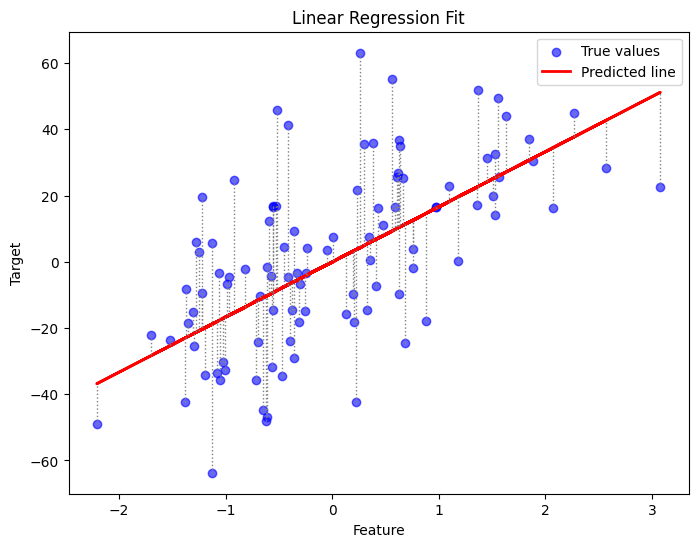

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

X, y = make_regression(
    n_samples=1000,
    n_features=1,   # 1D feature for easy plotting
    noise=20,       # noise to make it more realistic
    random_state=42
)


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='True values')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted line')

for i in range(len(X_test)):
    plt.plot([X_test[i], X_test[i]], [y_test[i], y_pred[i]], color='gray', linestyle=':', linewidth=1)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 458.3677
Mean Absolute Error (MAE): 17.0559
Root Mean Squared Error (RMSE): 21.4095
R-squared (R2): 0.3649
